# Regresión Logística: predicción de cancelación de pólizas (churn)
**Introducción a Machine Learning · Machine Learning Supervisado · Semana 6**

Autor: Santiago Moreno

## 1. Contexto del caso
Una aseguradora quiere anticipar qué clientes van a cancelar su póliza para actuar antes de perderlos (ofrecer un descuento, una llamada de retención, etc.). Se trata de un problema de **clasificación binaria**: el resultado es una categoría, no un valor continuo.

| Elemento | Variable | Descripción |
|---|---|---|
| Entrada X | `antiguedad_meses` | Meses que lleva el cliente con la póliza |
| Entrada X | `prima_mensual` | Valor de la prima mensual (COP) |
| Entrada X | `reclamos_12m` | Reclamos presentados en los últimos 12 meses |
| Entrada X | `contactos_soporte` | Veces que el cliente contactó a soporte |
| Objetivo y | `cancela` | 0 = renueva · 1 = cancela |

**Nota sobre los datos:** son sintéticos. Los generé yo mismo a partir de una relación logística conocida (sección 3), de modo que el dataset tenga un tamaño razonable (600 filas) y un desbalance moderado de clases. Así las métricas de evaluación sí tienen sentido, cosa que no pasa con las 16 filas del ejercicio guiado.

**Por qué importa el tipo de error:** en este caso los dos errores no cuestan lo mismo. Un falso negativo es un cliente que se va sin que lo hayamos detectado; un falso positivo es gastar una acción de retención en alguien que se iba a quedar igual. Esto se retoma en el análisis de umbrales.

## 2. Importar librerías

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report,
                             ConfusionMatrixDisplay, precision_score, recall_score,
                             f1_score, roc_auc_score, RocCurveDisplay)

## 3. Crear el conjunto de datos
Se simulan las cuatro variables de entrada y se construye la probabilidad de cancelación con una función logística. La lógica de negocio que le puse:

- más **antigüedad** → menos probabilidad de cancelar (cliente fidelizado);
- **prima** más alta → más probabilidad de cancelar;
- más **reclamos** y más **contactos a soporte** → más probabilidad de cancelar (señal de inconformidad).

Después, el valor de `cancela` se sortea con esa probabilidad (`binomial`), así que hay ruido y el modelo no puede acertar el 100 %. El intercepto (-2.5) se ajustó para que la tasa de cancelación quede alrededor del 25-30 %.

In [2]:
rng = np.random.default_rng(42)
n = 600

datos = pd.DataFrame({
    "antiguedad_meses": rng.integers(1, 61, n),
    "prima_mensual": rng.normal(80000, 25000, n).clip(30000).round(-3),
    "reclamos_12m": rng.poisson(1.2, n),
    "contactos_soporte": rng.poisson(2, n),
})

z = (-2.5
     - 0.05 * datos["antiguedad_meses"]
     + 0.00002 * datos["prima_mensual"]
     + 0.5 * datos["reclamos_12m"]
     + 0.3 * datos["contactos_soporte"])

datos["cancela"] = rng.binomial(1, 1 / (1 + np.exp(-z)))
datos.head()

,antiguedad_meses,prima_mensual,reclamos_12m,contactos_soporte,cancela
0,6,73000.0,0,3,0
1,47,77000.0,2,3,0
2,40,74000.0,0,1,0
3,27,84000.0,0,2,0
4,26,117000.0,0,1,0


**Preguntas rápidas de verificación**
- ¿Cuántas filas tiene el dataset? ¿Cuáles columnas son de entrada y cuál es el objetivo?
- ¿`cancela` es un número continuo o una categoría?

## 4. Explorar los datos

In [3]:
datos.info()

<class 'pandas.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   antiguedad_meses   600 non-null    int64  
 1   prima_mensual      600 non-null    float64
 2   reclamos_12m       600 non-null    int64  
 3   contactos_soporte  600 non-null    int64  
 4   cancela            600 non-null    int64  
dtypes: float64(1), int64(4)
memory usage: 23.6 KB


In [4]:
datos.describe()

,antiguedad_meses,prima_mensual,reclamos_12m,contactos_soporte,cancela
count,600.000000,600.000000,600.000000,600.000000,600.000000
mean,30.516667,79348.333333,1.181667,1.975000,0.263333
std,17.388799,24743.498778,1.127290,1.437992,0.440809
min,1.000000,30000.000000,0.000000,0.000000,0.000000
25%,15.000000,62000.000000,0.000000,1.000000,0.000000
50%,30.000000,80000.000000,1.000000,2.000000,0.000000
75%,46.000000,96000.000000,2.000000,3.000000,1.000000
max,60.000000,159000.000000,7.000000,7.000000,1.000000


In [5]:
print(datos["cancela"].value_counts())
print()
print(datos["cancela"].value_counts(normalize=True).round(3))

cancela
0    442
1    158
Name: count, dtype: int64

cancela
0    0.737
1    0.263
Name: proportion, dtype: float64


Hay datos de las dos clases y la clase 1 (cancela) es minoritaria, alrededor de un cuarto del total. Es un desbalance moderado: no es extremo, pero ya obliga a no confiar solo en el Accuracy.

## 5. Visualizar la relación de las variables con la cancelación

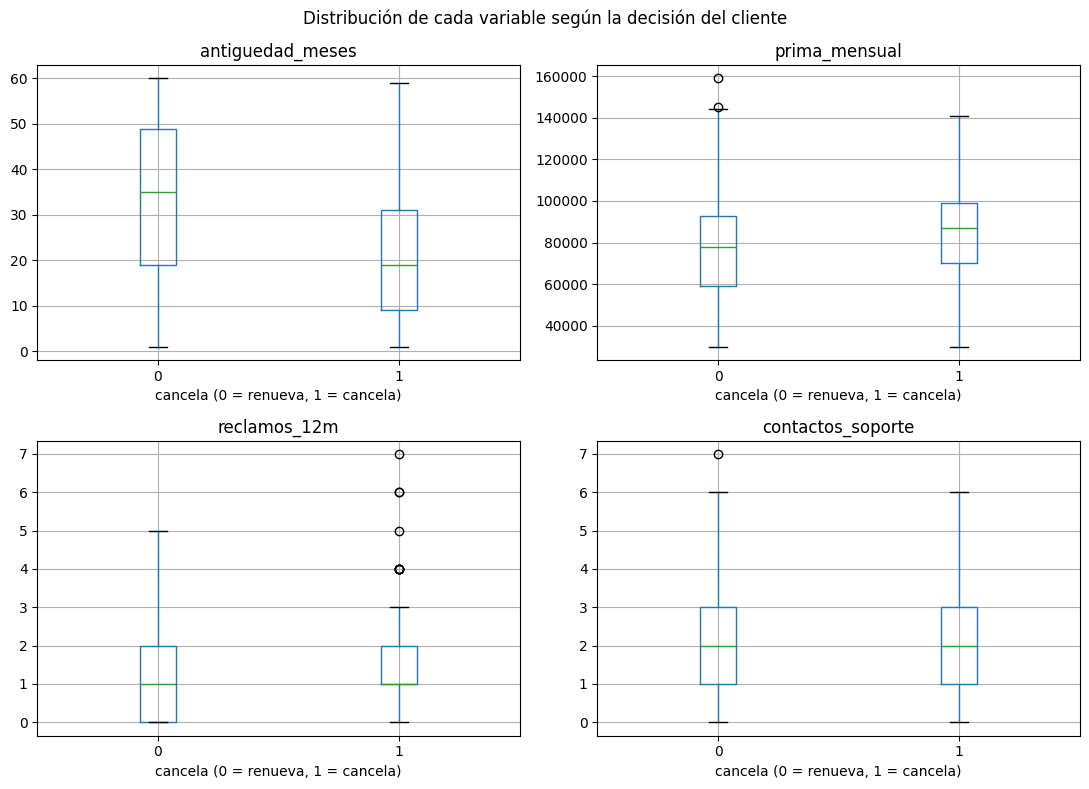

In [6]:
variables = ["antiguedad_meses", "prima_mensual", "reclamos_12m", "contactos_soporte"]

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for ax, var in zip(axes.ravel(), variables):
    datos.boxplot(column=var, by="cancela", ax=ax)
    ax.set_title(var)
    ax.set_xlabel("cancela (0 = renueva, 1 = cancela)")
plt.suptitle("Distribución de cada variable según la decisión del cliente")
plt.tight_layout()
plt.show()

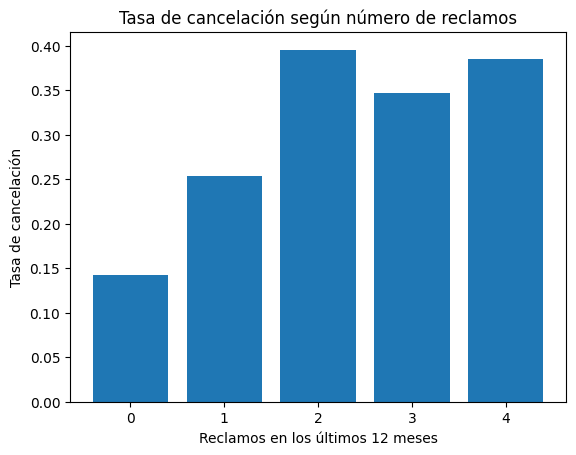

In [7]:
tasa = datos.groupby("reclamos_12m")["cancela"].agg(["mean", "count"])
tasa = tasa[tasa["count"] >= 10]

plt.bar(tasa.index, tasa["mean"])
plt.xlabel("Reclamos en los últimos 12 meses")
plt.ylabel("Tasa de cancelación")
plt.title("Tasa de cancelación según número de reclamos")
plt.show()

**Pregunta de interpretación:** ¿qué variables parecen separar mejor a quienes cancelan de quienes renuevan? Se responde en la sección 14.

## 6. Definir X y y

In [8]:
X = datos[["antiguedad_meses", "prima_mensual", "reclamos_12m", "contactos_soporte"]]
y = datos["cancela"]

print(X.head())
print(y.head())

   antiguedad_meses  prima_mensual  reclamos_12m  contactos_soporte
0                 6        73000.0             0                  3
1                47        77000.0             2                  3
2                40        74000.0             0                  1
3                27        84000.0             0                  2
4                26       117000.0             0                  1
0    0
1    0
2    0
3    0
4    0
Name: cancela, dtype: int64


## 7. Dividir entrenamiento y prueba
Uso 25 % para prueba (150 filas), `random_state=42` para que sea reproducible y `stratify=y` para conservar la proporción de cancelaciones en ambos conjuntos. Con el desbalance que hay, sin estratificar el conjunto de prueba podría quedar con una proporción de clase 1 muy distinta a la real.

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("Tamaño X_train:", X_train.shape)
print("Tamaño X_test:", X_test.shape)
print("\nDistribución train:")
print(y_train.value_counts(normalize=True).round(3))
print("\nDistribución test:")
print(y_test.value_counts(normalize=True).round(3))

Tamaño X_train: (450, 4)
Tamaño X_test: (150, 4)

Distribución train:
cancela
0    0.738
1    0.262
Name: proportion, dtype: float64

Distribución test:
cancela
0    0.733
1    0.267
Name: proportion, dtype: float64


## 8. Crear y entrenar el modelo
Las variables están en escalas muy distintas (la prima va en decenas de miles y los reclamos en unidades). Para que los coeficientes sean comparables y la optimización converja bien, estandarizo con `StandardScaler` dentro de un `Pipeline`.

Meter el escalador en el pipeline tiene una ventaja importante: el `fit` calcula media y desviación **solo con los datos de entrenamiento**, y al predecir sobre el conjunto de prueba aplica esos mismos valores. Si escalara todo el dataset antes de dividir, la información del conjunto de prueba se filtraría al entrenamiento (fuga de datos).

In [10]:
modelo = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(max_iter=1000))
])

modelo.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('logreg', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not w

## 9. Predecir clases y probabilidades

In [11]:
y_pred = modelo.predict(X_test)
probabilidades = modelo.predict_proba(X_test)

print("Primeras 10 clases predichas:", y_pred[:10])
print("\nPrimeras 10 probabilidades [P(renueva), P(cancela)]:")
print(probabilidades[:10].round(3))

Primeras 10 clases predichas: [1 0 0 0 0 0 0 0 0 0]

Primeras 10 probabilidades [P(renueva), P(cancela)]:
[[0.323 0.677]
 [0.673 0.327]
 [0.639 0.361]
 [0.883 0.117]
 [0.694 0.306]
 [0.793 0.207]
 [0.692 0.308]
 [0.923 0.077]
 [0.742 0.258]
 [0.882 0.118]]


In [12]:
comparacion = pd.DataFrame({
    "Real": y_test.values,
    "Predicho": y_pred,
    "Prob_Renueva": probabilidades[:, 0],
    "Prob_Cancela": probabilidades[:, 1]
})
comparacion.head(15)

,Real,Predicho,Prob_Renueva,Prob_Cancela
0,1,1,0.323476,0.676524
1,0,0,0.673169,0.326831
2,0,0,0.638625,0.361375
3,1,0,0.882688,0.117312
4,0,0,0.693634,0.306366
5,0,0,0.793332,0.206668
6,0,0,0.691554,0.308446
7,0,0,0.923399,0.076601
8,1,0,0.742248,0.257752
9,0,0,0.882329,0.117671


`predict()` devuelve la clase final y `predict_proba()` la probabilidad de cada clase. Con el umbral por defecto (0.50), la predicción es 1 cuando `Prob_Cancela` es igual o mayor a 0.50.

## 10. Evaluar el modelo

In [13]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", round(accuracy, 3))

print("\nMatriz de confusión:")
print(confusion_matrix(y_test, y_pred))

print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred, target_names=["Renueva", "Cancela"]))

Accuracy: 0.78

Matriz de confusión:
[[105   5]
 [ 28  12]]

Reporte de clasificación:
              precision    recall  f1-score   support

     Renueva       0.79      0.95      0.86       110
     Cancela       0.71      0.30      0.42        40

    accuracy                           0.78       150
   macro avg       0.75      0.63      0.64       150
weighted avg       0.77      0.78      0.75       150



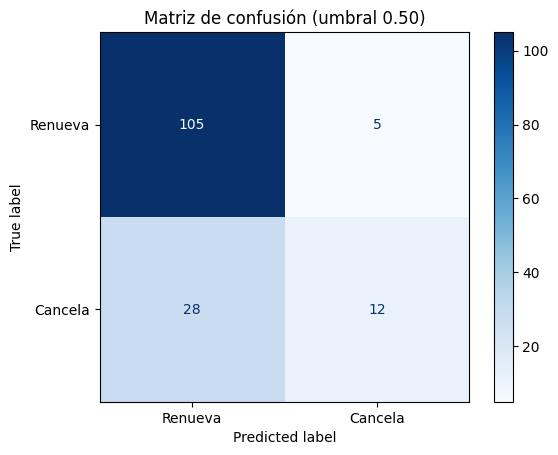

In [14]:
ConfusionMatrixDisplay.from_estimator(
    modelo, X_test, y_test,
    display_labels=["Renueva", "Cancela"],
    cmap="Blues"
)
plt.title("Matriz de confusión (umbral 0.50)")
plt.show()

ROC-AUC: 0.735


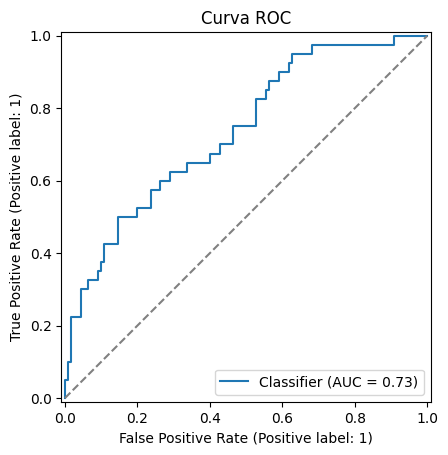

In [15]:
proba_cancela = probabilidades[:, 1]
print("ROC-AUC:", round(roc_auc_score(y_test, proba_cancela), 3))

RocCurveDisplay.from_predictions(y_test, proba_cancela)
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.title("Curva ROC")
plt.show()

Cómo leer cada métrica en este caso (clase positiva = cancela):

| Métrica | Pregunta que responde aquí |
|---|---|
| Accuracy | ¿Qué porcentaje de clientes clasificó bien en total? |
| Precision | Cuando el modelo dijo "cancela", ¿cuántas veces acertó? |
| Recall | De los clientes que realmente cancelaron, ¿a cuántos detectó? |
| F1-score | Equilibrio entre Precision y Recall |
| ROC-AUC | ¿Qué tan bien ordena el modelo a los que cancelan por encima de los que renuevan, sin importar el umbral? |

## 11. Cambiar el umbral de decisión
El umbral de 0.50 es una convención, no una regla. Si dejar ir a un cliente cuesta más que gastar una acción de retención de más, conviene bajar el umbral: se detectan más cancelaciones (sube el Recall) a cambio de más falsas alarmas (baja la Precision). Por eso barro varios valores en lugar de probar uno solo.

In [16]:
filas = []
for u in [0.2, 0.3, 0.4, 0.5, 0.6, 0.7]:
    pred_u = (proba_cancela >= u).astype(int)
    filas.append({
        "umbral": u,
        "clientes_marcados": int(pred_u.sum()),
        "precision": precision_score(y_test, pred_u, zero_division=0),
        "recall": recall_score(y_test, pred_u),
        "f1": f1_score(y_test, pred_u)
    })

tabla_umbrales = pd.DataFrame(filas).round(3)
tabla_umbrales

,umbral,clientes_marcados,precision,recall,f1
0,0.2,66,0.394,0.650,0.491
1,0.3,42,0.476,0.500,0.488
2,0.4,27,0.556,0.375,0.448
3,0.5,17,0.706,0.300,0.421
4,0.6,5,0.800,0.100,0.178
5,0.7,0,0.000,0.000,0.000


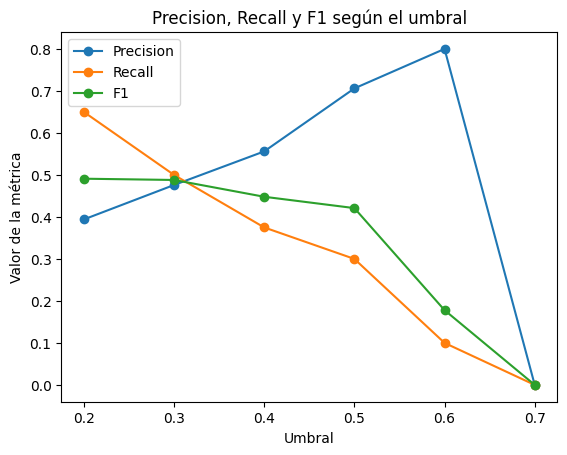

In [17]:
plt.plot(tabla_umbrales["umbral"], tabla_umbrales["precision"], marker="o", label="Precision")
plt.plot(tabla_umbrales["umbral"], tabla_umbrales["recall"], marker="o", label="Recall")
plt.plot(tabla_umbrales["umbral"], tabla_umbrales["f1"], marker="o", label="F1")
plt.xlabel("Umbral")
plt.ylabel("Valor de la métrica")
plt.title("Precision, Recall y F1 según el umbral")
plt.legend()
plt.show()

## 12. Interpretar los coeficientes
Como las variables están estandarizadas, cada coeficiente indica cuánto cambia el log-odds de cancelar por cada aumento de **una desviación estándar** en la variable, y se pueden comparar entre sí. Al aplicar `exp()` se obtiene el **odds ratio**: mayor a 1 aumenta las probabilidades de cancelar, menor a 1 las reduce.

In [18]:
coefs = pd.Series(modelo.named_steps["logreg"].coef_[0], index=X.columns)

interpretacion = pd.DataFrame({
    "coeficiente": coefs,
    "odds_ratio": np.exp(coefs)
}).sort_values("coeficiente", ascending=False).round(3)

interpretacion

,coeficiente,odds_ratio
prima_mensual,0.555,1.742
reclamos_12m,0.431,1.539
contactos_soporte,0.287,1.333
antiguedad_meses,-0.988,0.372


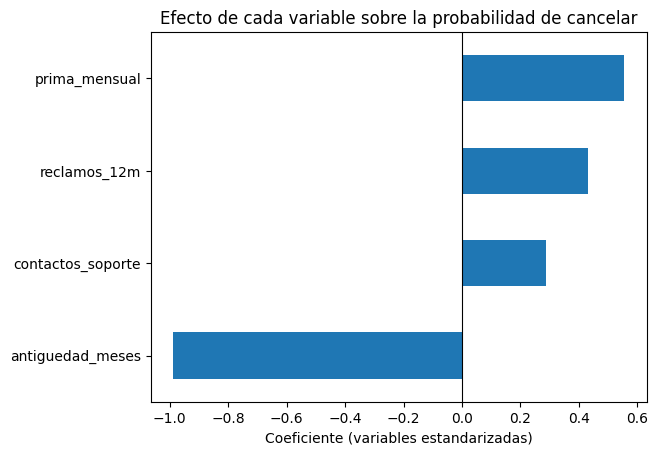

In [19]:
interpretacion["coeficiente"].sort_values().plot(kind="barh")
plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("Coeficiente (variables estandarizadas)")
plt.title("Efecto de cada variable sobre la probabilidad de cancelar")
plt.show()

## 13. Estabilidad de los resultados con distintas particiones
Una sola partición puede dar métricas optimistas o pesimistas por azar. Repito el entrenamiento con 5 semillas distintas para ver cuánto varían los resultados.

In [20]:
resultados = []
for semilla in [1, 7, 21, 42, 99]:
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.25, random_state=semilla, stratify=y)
    m = Pipeline([("scaler", StandardScaler()), ("logreg", LogisticRegression(max_iter=1000))])
    m.fit(Xtr, ytr)
    p = m.predict(Xte)
    resultados.append({
        "semilla": semilla,
        "accuracy": accuracy_score(yte, p),
        "precision": precision_score(yte, p),
        "recall": recall_score(yte, p),
        "auc": roc_auc_score(yte, m.predict_proba(Xte)[:, 1])
    })

pd.DataFrame(resultados).round(3)

,semilla,accuracy,precision,recall,auc
0,1,0.747,0.545,0.300,0.752
1,7,0.773,0.667,0.300,0.750
2,21,0.727,0.476,0.250,0.700
3,42,0.780,0.706,0.300,0.735
4,99,0.767,0.647,0.275,0.745


## 14. Respuestas e interpretación

**1. ¿Por qué es un problema de clasificación y no de regresión?**
Porque lo que quiero predecir es una categoría (el cliente renueva o cancela), no una cantidad. Aunque la regresión logística lleve "regresión" en el nombre, lo que estima es la probabilidad de pertenecer a una clase y con eso asigna la etiqueta.

**2. ¿Qué significa que `cancela` tome valores 0 y 1?**
Son etiquetas de clase: 0 es "renueva" y 1 es "cancela". El 1 es la clase positiva, la que me interesa detectar, y todas las métricas de Precision y Recall se leen respecto a ella.

**3. ¿Qué hace `fit()`?**
Es el momento en que el modelo aprende. En el pipeline, el escalador calcula la media y la desviación del conjunto de entrenamiento y la regresión logística ajusta los coeficientes que mejor separan las dos clases en esos datos.

**4. ¿Diferencia entre `predict()` y `predict_proba()`?**
`predict_proba()` entrega la probabilidad estimada de cada clase; `predict()` aplica un umbral (0.50 por defecto) sobre esa probabilidad y devuelve solo la clase final. Quedarse con las probabilidades da más control, porque permite mover el umbral según el costo de cada error, como se hizo en la sección 11.

**5. ¿Qué indica la matriz de confusión?**
Con el umbral de 0.50, de 150 clientes de prueba el modelo acertó 105 que renuevan (verdaderos negativos) y 12 que cancelan (verdaderos positivos). Se equivocó en 5 casos al decir que cancelaban cuando renovaron (falsos positivos) y en 28 casos al no detectar a quien sí canceló (falsos negativos). El error dominante es el segundo.

**6. ¿Qué métrica es más útil y por qué?**
El Accuracy da 0.78, que a simple vista parece bueno, pero es engañoso: si el modelo dijera siempre "renueva" acertaría el 73 % (110 de 150) sin aprender nada. El Recall de la clase "cancela" es de apenas 0.30, es decir, el modelo detecta menos de un tercio de las cancelaciones reales. Para este negocio la métrica más útil es el Recall de la clase positiva, mirada junto con la Precision (y el F1 como resumen). El ROC-AUC (0.735) complementa porque no depende del umbral y muestra que el modelo sí ordena mejor que el azar, pero no de forma excelente.

**7. ¿Qué pasaría con un conjunto mucho más grande y desbalanceado?**
El Accuracy se vuelve todavía menos confiable: con 2 % de positivos, un modelo que nunca predice la clase minoritaria tendría 98 % de Accuracy y sería inútil. Habría que apoyarse en Precision, Recall, F1 y curvas ROC o Precision-Recall, mantener `stratify`, considerar `class_weight="balanced"` o técnicas de remuestreo y ajustar el umbral. Este mismo ejercicio ya muestra el efecto en pequeño: con 26 % de positivos el Recall quedó en 0.30.

**Análisis del umbral.** Bajar el umbral de 0.50 a 0.30 sube el Recall de 0.30 a 0.50 (se detecta la mitad de las cancelaciones) y la Precision baja de 0.71 a 0.48. Con 0.20 el Recall llega a 0.65, pero la Precision cae a 0.39: de 66 clientes marcados, solo 26 realmente se iban. Qué umbral escoger depende de cuánto cueste una acción de retención frente al valor de un cliente que se pierde. Si retener es barato, un umbral entre 0.20 y 0.30 tiene sentido; si es caro, conviene uno más alto. A 0.70 el modelo ya no marca a nadie, lo que muestra que las probabilidades que entrega son moderadas.

**Interpretación de coeficientes.** La antigüedad es la variable con mayor peso y reduce la probabilidad de cancelar (odds ratio de 0.37 por cada desviación estándar). Le siguen la prima mensual (1.74), los reclamos (1.54) y los contactos a soporte (1.33), que la aumentan. Esto coincide con la lógica con la que se generaron los datos, lo cual era de esperar al ser sintéticos, y confirma que el modelo recupera la señal.

**Estabilidad.** Con cinco particiones distintas el Accuracy se movió entre 0.73 y 0.78 y el Recall entre 0.25 y 0.30, así que la conclusión (buen Accuracy aparente, Recall bajo) se mantiene y no depende de una partición afortunada o desafortunada.

## 15. Limitaciones
- Los datos son simulados: los resultados muestran el proceso, no el comportamiento real de clientes de una aseguradora.
- El desbalance es moderado; en un caso real puede ser mucho más fuerte.
- Se usó un solo modelo y sin ajuste de hiperparámetros; no se probó `class_weight` ni otros algoritmos de clasificación.
- La separación entre clases es limitada (AUC cercano a 0.74), en parte por el ruido que se agregó a propósito al generar la variable objetivo.